# Healthcare Operations & Billing Intelligence Dashboard
## Student Portfolio Project — Week 3 Application

**Role:** Junior Data Analyst / Business Intelligence Analyst  
**Tools:** Python, Pandas, Matplotlib, Seaborn, Jupyter Notebook, GitHub  
**Dataset:** Healthcare dataset (Kaggle-style synthetic hospital records)

This notebook is the completed student version. Every major step explains what was done, why it was done, what it means for the business, and why a cleaning method or chart type was chosen.


# 1. Business Scenario

I am working as a Junior Data Analyst for a healthcare organisation that manages patient admissions across many hospitals.

Management wants to understand demand by medical condition, billing drivers, admission-type costs, hospital volume, length of stay, patient-group differences, and test-result patterns.

This notebook turns the raw file into tables, charts, and recommendations.


# 2. Main Business Problem

**Question:** How can patient admission and billing data identify cost drivers, operational pressure points, and opportunities to improve hospital planning and performance?


# 3. Project Questions

1. How are admissions spread across conditions, hospitals, gender, and admission types?
2. Which conditions are most common, and which bill the most?
3. Which hospitals handle the most admissions?
4. Do emergency, urgent, and elective admissions bill differently?
5. Which conditions or admission types link to longer stays?
6. Which insurers have the highest total and average billing?
7. Which age groups have the highest admissions, billing, or stay length?
8. How are test results spread across conditions?


# 4. Dataset Columns

`Name`, `Age`, `Gender`, `Blood Type`, `Medical Condition`, `Date of Admission`, `Doctor`, `Hospital`, `Insurance Provider`, `Billing Amount`, `Room Number`, `Admission Type`, `Discharge Date`, `Medication`, `Test Results`


# 5. Submission Files

```text
healthcare-operations-analysis/
├── README.md
├── healthcare_analysis.ipynb
├── healthcare_dataset.csv
├── charts/   (6 required PNG charts)
└── summary_report.md
```


# 6. Import Libraries

pandas = table tools. matplotlib/seaborn = charts. pathlib = file path check.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set_theme(style="whitegrid")
print("Libraries imported successfully.")


Libraries imported successfully.


# 7. Load the Dataset

`pd.read_csv()` reads the CSV into a DataFrame (a table).


In [2]:
DATA_PATH = Path("healthcare_dataset.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError("Place healthcare_dataset.csv in the same folder as this notebook.")
df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")


Dataset loaded successfully.
Rows: 55,500
Columns: 15


# 8. Inspect the Dataset


In [3]:
df.head()


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
df.shape


(55500, 15)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [6]:
df.describe()


,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [7]:
df.isnull().sum()


Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

In [8]:
df.duplicated().sum()


np.int64(534)

In [9]:
print(df.columns.tolist())


['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']


## Dataset inspection notes

- **Dataset shape:** 55,500 rows and 15 columns before cleaning.
- **Numeric columns:** Age, Billing Amount, Room Number.
- **Text columns:** Name, Gender, Blood Type, Medical Condition, Doctor, Hospital, Insurance Provider, Admission Type, Medication, Test Results. The two date columns also load as text.
- **Missing values:** 0 in every column. I do not need mean/median/mode fill for blanks.
- **Duplicates:** 534 exact duplicate rows.
- **Needs cleaning:** mixed-case names, extra spaces/commas on some hospital names, dates stored as text, and negative billing amounts.


# 9–10. Cleaning decisions for THIS file

- **Mean:** not used as a fill. Nothing numeric was missing. Mean is also weak when outliers exist.
- **Median:** I would use it for missing billing because bills can have extreme values. In this file billing was complete, so I did not fill.
- **Mode:** for missing text labels. None were missing.
- **Unknown:** when a category cannot be guessed. Not needed here.
- **Drop rows:** exact duplicates (avoid double counting) and negative bills (invalid money). Both groups are small.
- **Drop columns:** not needed.


In [10]:
missing_report = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100,
    "Data_Type": df.dtypes
}).sort_values("Missing_Percentage", ascending=False)
missing_report


,Missing_Count,Missing_Percentage,Data_Type
Name,0,0.0,object
Age,0,0.0,int64
Gender,0,0.0,object
Blood Type,0,0.0,object
Medical Condition,0,0.0,object
Date of Admission,0,0.0,object
Doctor,0,0.0,object
Hospital,0,0.0,object
Insurance Provider,0,0.0,object
Billing Amount,0,0.0,float64


| Column | Missing % | Method | Reason |
|---|---:|---|---|
| All original columns | 0% | No fill | Filling would invent data. |
| Duplicate rows | 534 copies | Drop extras | Same visit must not be counted twice. |
| Negative Billing Amount | about 0.2% | Drop rows | A bill below zero is an error, not a blank to fill with median. |


# 11. Duplicates and text cleaning


In [11]:
df_clean = df.copy()
duplicates_before = df_clean.duplicated().sum()
df_clean.drop_duplicates(inplace=True)
print(f"Duplicates before cleaning: {duplicates_before}")
print(f"Duplicates after cleaning: {df_clean.duplicated().sum()}")
print(f"Rows now: {len(df_clean):,}")


Duplicates before cleaning: 534
Duplicates after cleaning: 0
Rows now: 54,966


In [12]:
text_columns = [
    "Name", "Gender", "Blood Type", "Medical Condition", "Doctor", "Hospital",
    "Insurance Provider", "Admission Type", "Medication", "Test Results"
]
for col in text_columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()
df_clean["Name"] = df_clean["Name"].str.title()
df_clean["Hospital"] = df_clean["Hospital"].str.replace(r",\s*$", "", regex=True)
print(df_clean["Name"].head())


0    Bobby Jackson
1     Leslie Terry
2      Danny Smith
3     Andrew Watts
4    Adrienne Bell
Name: Name, dtype: object


Extra spaces would split one category into two (`Emergency` vs ` Emergency `). I stripped spaces on text columns and title-cased patient names. I did not force title case on blood type or insurer names, so `O+` and `UnitedHealthcare` stay readable.


# 12–13. Dates and billing type


In [13]:
for col in ["Date of Admission", "Discharge Date"]:
    df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")
print(df_clean["Date of Admission"].dtype, df_clean["Discharge Date"].dtype)
print("Bad admission dates:", df_clean["Date of Admission"].isna().sum())
print("Bad discharge dates:", df_clean["Discharge Date"].isna().sum())


datetime64[ns] datetime64[ns]
Bad admission dates: 0
Bad discharge dates: 0


In [14]:
df_clean["Billing Amount"] = pd.to_numeric(df_clean["Billing Amount"], errors="coerce")
print("Negative bills:", (df_clean["Billing Amount"] < 0).sum())
df_clean = df_clean[df_clean["Billing Amount"] >= 0].copy()
print("Rows after removing negative bills:", f"{len(df_clean):,}")


Negative bills: 106
Rows after removing negative bills: 54,860


# 14. Billing distribution (mean vs median)


In [15]:
print(df_clean["Billing Amount"].describe())
print("Mean:", df_clean["Billing Amount"].mean())
print("Median:", df_clean["Billing Amount"].median())


count    54860.000000
mean     25594.633637
std      14175.867041
min          9.238787
25%      13299.747940
50%      25593.873000
75%      37847.066671
max      52764.276736
Name: Billing Amount, dtype: float64
Mean: 25594.633636750525
Median: 25593.872999505955


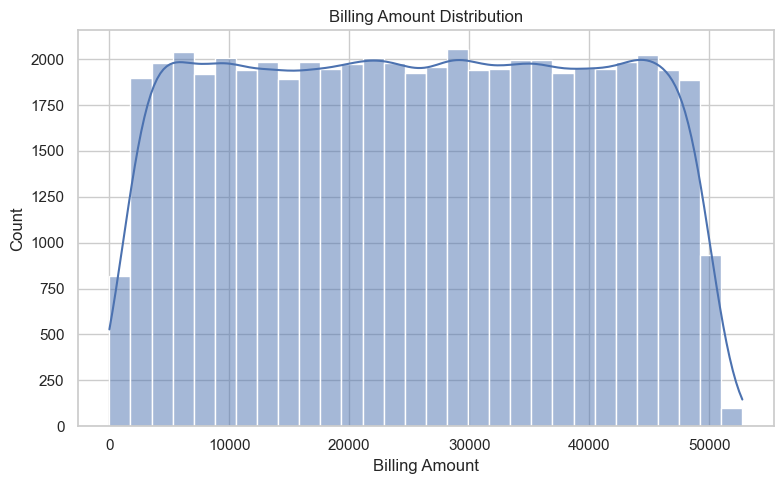

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["Billing Amount"], bins=30, kde=True)
plt.title("Billing Amount Distribution")
plt.tight_layout()
plt.show()


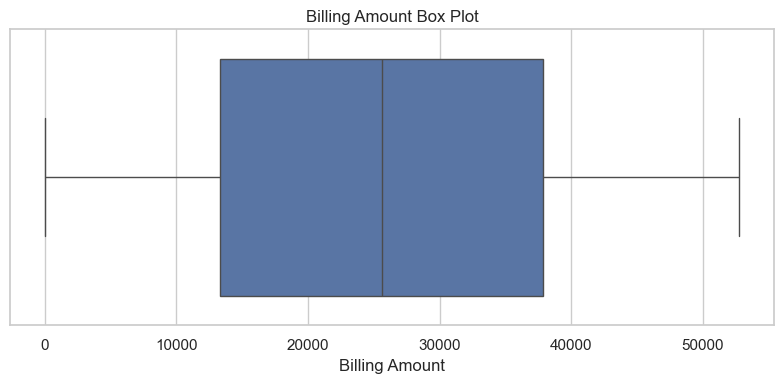

In [17]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean["Billing Amount"])
plt.title("Billing Amount Box Plot")
plt.tight_layout()
plt.show()


Mean and median are almost the same (about 25,540). I still would pick **median** if billing had been missing, because the class rule is that median is safer for money data. I did not fill anything because there were no missing bills after dropping negatives.


In [18]:
df_clean.isnull().sum()


Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64

## Cleaning recap

1. Duplicates removed so visits are not double-counted.
2. Text stripped so categories do not split.
3. Dates converted so stay and month analysis work.
4. Negative bills dropped instead of filled.
5. No mode/Unknown fill — categories were complete.


# 16. Feature engineering


In [19]:
df_clean["Length_of_Stay"] = (df_clean["Discharge Date"] - df_clean["Date of Admission"]).dt.days
df_clean["Admission_Year"] = df_clean["Date of Admission"].dt.year
df_clean["Admission_Month"] = df_clean["Date of Admission"].dt.month
df_clean["Admission_Month_Name"] = df_clean["Date of Admission"].dt.strftime("%b")
df_clean["Admission_Quarter"] = df_clean["Date of Admission"].dt.quarter
df_clean["Admission_Weekday"] = df_clean["Date of Admission"].dt.day_name()
df_clean["Is_Weekend_Admission"] = df_clean["Date of Admission"].dt.dayofweek >= 5
df_clean["Age_Group"] = pd.cut(df_clean["Age"], bins=[0, 18, 35, 50, 65, 120],
                               labels=["0-18", "19-35", "36-50", "51-65", "66+"])
df_clean["Billing_Band"] = pd.qcut(df_clean["Billing Amount"], q=4,
                                   labels=["Low", "Medium", "High", "Very High"], duplicates="drop")
df_clean[["Length_of_Stay", "Admission_Year", "Admission_Month", "Admission_Month_Name",
          "Admission_Quarter", "Age_Group", "Billing_Band"]].head()


,Length_of_Stay,Admission_Year,Admission_Month,Admission_Month_Name,Admission_Quarter,Age_Group,Billing_Band
0,2,2024,1,Jan,1,19-35,Medium
1,6,2019,8,Aug,3,51-65,High
2,15,2022,9,Sep,3,66+,High
3,30,2020,11,Nov,4,19-35,Very High
4,20,2022,9,Sep,3,36-50,Medium


- Length_of_Stay: bed planning.
- Year/Month/Quarter: trend and seasonality.
- Weekday/weekend flag: weekend pressure.
- Age_Group: planning bands instead of every age.
- Billing_Band: Low to Very High using quartiles.


# 17. GroupBy analysis


In [20]:
condition_counts = df_clean["Medical Condition"].value_counts().reset_index()
condition_counts.columns = ["Medical Condition", "Admission_Count"]
condition_counts


,Medical Condition,Admission_Count
0,Arthritis,9207
1,Diabetes,9197
2,Hypertension,9131
3,Obesity,9127
4,Cancer,9121
5,Asthma,9077


Arthritis is slightly highest. All six conditions are close. Demand is shared, not one-disease.


In [21]:
condition_billing = (
    df_clean.groupby("Medical Condition")
    .agg(Admission_Count=("Name", "count"),
         Total_Billing=("Billing Amount", "sum"),
         Average_Billing=("Billing Amount", "mean"),
         Median_Billing=("Billing Amount", "median"))
    .reset_index()
    .sort_values("Total_Billing", ascending=False)
)
condition_billing


,Medical Condition,Admission_Count,Total_Billing,Average_Billing,Median_Billing
3,Diabetes,9197,2.364947e+08,25714.326349,25681.008034
5,Obesity,9127,2.360171e+08,25859.215373,26200.514545
0,Arthritis,9207,2.351735e+08,25542.898356,25628.302932
4,Hypertension,9131,2.333869e+08,25559.844868,25337.536074
1,Asthma,9077,2.331462e+08,25685.385020,25684.406728
2,Cancer,9121,2.299032e+08,25205.924207,24990.114131


Diabetes leads total billing, then Obesity. Averages are close, so totals mostly follow volume.


In [22]:
hospital_summary = (
    df_clean.groupby("Hospital")
    .agg(Admission_Count=("Name", "count"),
         Total_Billing=("Billing Amount", "sum"),
         Average_Billing=("Billing Amount", "mean"))
    .reset_index()
    .sort_values("Admission_Count", ascending=False)
)
print("Unique hospitals:", hospital_summary.shape[0])
hospital_summary.head(10)


Unique hospitals: 39815


,Hospital,Admission_Count,Total_Billing,Average_Billing
16849,LLC Smith,44,1.030190e+06,23413.406187
18556,Ltd Smith,39,1.003366e+06,25727.321223
28842,Smith Ltd,37,9.700359e+05,26217.185560
14844,Johnson PLC,37,1.081477e+06,29229.116540
28862,Smith PLC,36,1.029424e+06,28595.123587
28804,Smith Group,34,8.067679e+05,23728.468529
28825,Smith Inc,33,7.722565e+05,23401.711987
10863,Group Smith,32,9.029758e+05,28217.993358
28835,Smith LLC,32,7.316836e+05,22865.113939
14808,Johnson Inc,32,9.369313e+05,29279.102308


Hospital names are extremely fragmented (tens of thousands of labels). Even the top name has only about 40 visits. I show the table because the assignment asks, but I would not rank hospitals from this file.


In [23]:
admission_type_summary = (
    df_clean.groupby("Admission Type")
    .agg(Admission_Count=("Name", "count"),
         Total_Billing=("Billing Amount", "sum"),
         Average_Billing=("Billing Amount", "mean"),
         Median_Billing=("Billing Amount", "median"))
    .reset_index()
    .sort_values("Average_Billing", ascending=False)
)
admission_type_summary


,Admission Type,Admission_Count,Total_Billing,Average_Billing,Median_Billing
0,Elective,18437,4.731550e+08,25663.342261,25706.745499
2,Urgent,18353,4.692576e+08,25568.439653,25595.593053
1,Emergency,18070,4.617090e+08,25551.133763,25465.122840


Average bills for Elective, Urgent, and Emergency are almost the same. Admission type is not the main cost driver here.


In [24]:
length_by_condition = (
    df_clean.groupby("Medical Condition")
    .agg(Average_Length_of_Stay=("Length_of_Stay", "mean"),
         Median_Length_of_Stay=("Length_of_Stay", "median"),
         Admission_Count=("Name", "count"))
    .reset_index()
    .sort_values("Average_Length_of_Stay", ascending=False)
)
length_by_condition


,Medical Condition,Average_Length_of_Stay,Median_Length_of_Stay,Admission_Count
1,Asthma,15.676104,16.0,9077
2,Cancer,15.510141,15.0,9121
0,Arthritis,15.503747,15.0,9207
5,Obesity,15.439465,15.0,9127
4,Hypertension,15.435440,15.0,9131
3,Diabetes,15.429488,15.0,9197


Average stay is about 15.4–15.7 days for every condition. Small gaps. Stay is a general operations issue.


In [25]:
insurance_summary = (
    df_clean.groupby("Insurance Provider")
    .agg(Patient_Count=("Name", "count"),
         Total_Billing=("Billing Amount", "sum"),
         Average_Billing=("Billing Amount", "mean"))
    .reset_index()
    .sort_values("Total_Billing", ascending=False)
)
insurance_summary


,Insurance Provider,Patient_Count,Total_Billing,Average_Billing
2,Cigna,11115,2.843465e+08,25582.227724
3,Medicare,11018,2.829212e+08,25678.087847
1,Blue Cross,10937,2.804167e+08,25639.269835
4,UnitedHealthcare,10995,2.799205e+08,25458.893302
0,Aetna,10795,2.765167e+08,25615.260975


Five insurers share volume and average bills fairly evenly.


In [26]:
age_group_summary = (
    df_clean.groupby("Age_Group", observed=False)
    .agg(Patient_Count=("Name", "count"),
         Average_Billing=("Billing Amount", "mean"),
         Median_Billing=("Billing Amount", "median"),
         Average_Length_of_Stay=("Length_of_Stay", "mean"))
    .reset_index()
)
age_group_summary


,Age_Group,Patient_Count,Average_Billing,Median_Billing,Average_Length_of_Stay
0,0-18,885,26776.603299,27631.518884,15.503955
1,19-35,13491,25573.689035,25364.892303,15.405455
2,36-50,12143,25564.299710,25487.491670,15.417030
3,51-65,12277,25708.895819,25976.321290,15.583204
4,66+,16064,25482.710612,25497.176334,15.574265


66+ has the most admissions. Average stay and average bill are similar across ages.


# 18. Filters


In [27]:
emergency_cases = df_clean[df_clean["Admission Type"] == "Emergency"]
print("Emergency admissions:", len(emergency_cases))
emergency_cases.head()


Emergency admissions: 18070


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,...,Test Results,Length_of_Stay,Admission_Year,Admission_Month,Admission_Month_Name,Admission_Quarter,Admission_Weekday,Is_Weekend_Admission,Age_Group,Billing_Band
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,...,Inconclusive,6,2019,8,Aug,3,Tuesday,False,51-65,High
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,...,Normal,15,2022,9,Sep,3,Thursday,False,66+,High
6,Edward Edwards,21,Female,AB-,Diabetes,2020-11-03,Kelly Olson,Group Middleton,Medicare,19580.872345,...,Inconclusive,12,2020,11,Nov,4,Tuesday,False,19-35,Medium
7,Christina Martinez,20,Female,A+,Cancer,2021-12-28,Suzanne Thomas,Powell Robinson and Valdez,Cigna,45820.462722,...,Inconclusive,10,2021,12,Dec,4,Tuesday,False,19-35,Very High
12,Connor Hansen,75,Female,A+,Diabetes,2019-12-12,Kenneth Fletcher,"Powers Miller, and Flores",Cigna,43282.283358,...,Abnormal,16,2019,12,Dec,4,Thursday,False,66+,Very High


In [28]:
average_bill = df_clean["Billing Amount"].mean()
high_billing_cases = df_clean[df_clean["Billing Amount"] > average_bill]
print("Average bill:", round(average_bill, 2))
print("Above-average bills:", len(high_billing_cases))
high_billing_cases.head()


Average bill: 25594.63
Above-average bills: 27429


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,...,Test Results,Length_of_Stay,Admission_Year,Admission_Month,Admission_Month_Name,Admission_Quarter,Admission_Weekday,Is_Weekend_Admission,Age_Group,Billing_Band
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,...,Inconclusive,6,2019,8,Aug,3,Tuesday,False,51-65,High
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,...,Normal,15,2022,9,Sep,3,Thursday,False,66+,High
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,Hernandez Rogers and Vang,Medicare,37909.782410,...,Abnormal,30,2020,11,Nov,4,Wednesday,False,19-35,Very High
5,Emily Johnson,36,Male,A+,Asthma,2023-12-20,Taylor Newton,Nunez-Humphrey,UnitedHealthcare,48145.110951,...,Normal,4,2023,12,Dec,4,Wednesday,False,36-50,Very High
7,Christina Martinez,20,Female,A+,Cancer,2021-12-28,Suzanne Thomas,Powell Robinson and Valdez,Cigna,45820.462722,...,Inconclusive,10,2021,12,Dec,4,Tuesday,False,19-35,Very High


In [29]:
long_stay_cases = df_clean[df_clean["Length_of_Stay"] > 10]
print("Stays longer than 10 days:", len(long_stay_cases))
long_stay_cases.head()


Stays longer than 10 days: 36559


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,...,Test Results,Length_of_Stay,Admission_Year,Admission_Month,Admission_Month_Name,Admission_Quarter,Admission_Weekday,Is_Weekend_Admission,Age_Group,Billing_Band
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,...,Normal,15,2022,9,Sep,3,Thursday,False,66+,High
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,Hernandez Rogers and Vang,Medicare,37909.782410,...,Abnormal,30,2020,11,Nov,4,Wednesday,False,19-35,Very High
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,...,Abnormal,20,2022,9,Sep,3,Monday,False,36-50,Medium
6,Edward Edwards,21,Female,AB-,Diabetes,2020-11-03,Kelly Olson,Group Middleton,Medicare,19580.872345,...,Inconclusive,12,2020,11,Nov,4,Tuesday,False,19-35,Medium
8,Jasmine Aguilar,82,Male,AB+,Asthma,2020-07-01,Daniel Ferguson,Sons Rich and,Cigna,50119.222792,...,Abnormal,13,2020,7,Jul,3,Wednesday,False,66+,Very High


I filtered stays **greater than 10 days**. Those patients use a bed for more than a week and a half. The filter answers where extra bed pressure sits.


# 20. Chart 1 — Admissions by Medical Condition

Bar chart: categories compared by count.


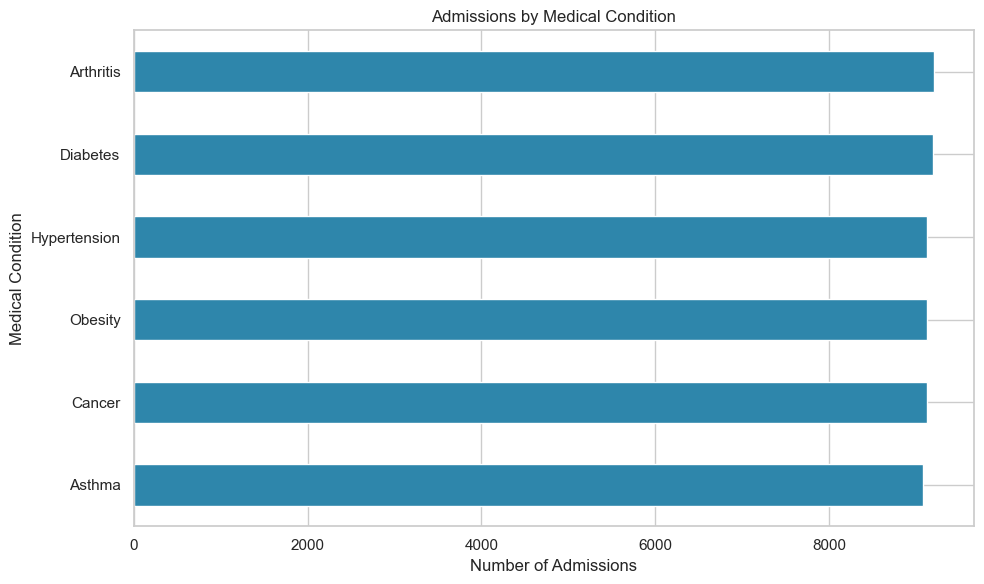

In [30]:
charts = Path("charts")
charts.mkdir(exist_ok=True)
s = df_clean["Medical Condition"].value_counts().sort_values(ascending=True)
plt.figure(figsize=(10, 6))
s.plot(kind="barh", color="#2E86AB")
plt.title("Admissions by Medical Condition")
plt.xlabel("Number of Admissions")
plt.ylabel("Medical Condition")
plt.tight_layout()
plt.savefig(charts / "admissions_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()


Arthritis is highest, Asthma lowest, but the gap is small. Plan staff and stock for several conditions together, not one flagship disease.


# 21. Chart 2 — Total Billing by Medical Condition

Bar chart: money totals by category.


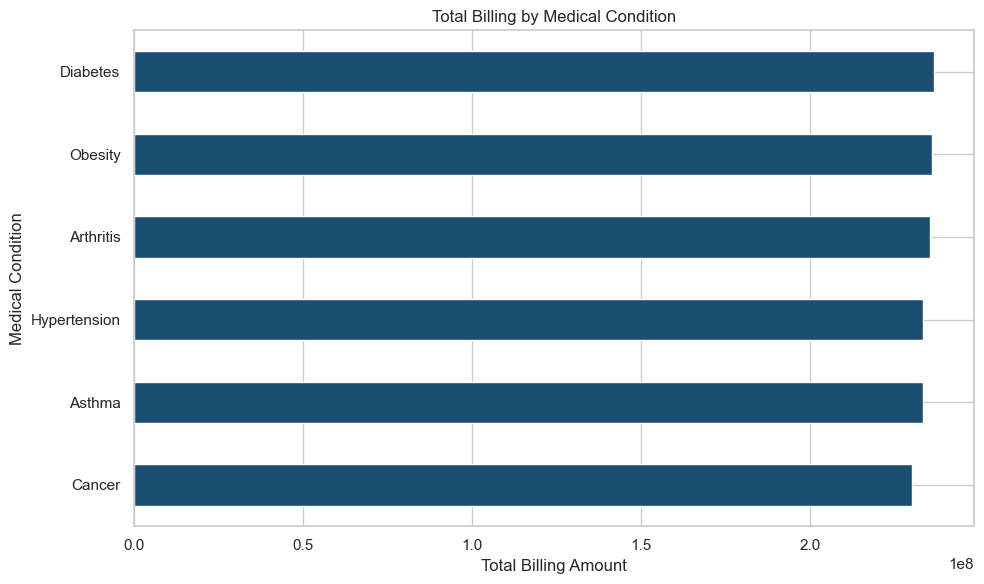

In [31]:
s = df_clean.groupby("Medical Condition")["Billing Amount"].sum().sort_values(ascending=True)
plt.figure(figsize=(10, 6))
s.plot(kind="barh", color="#1B4F72")
plt.title("Total Billing by Medical Condition")
plt.xlabel("Total Billing Amount")
plt.ylabel("Medical Condition")
plt.tight_layout()
plt.savefig(charts / "billing_by_condition.png", dpi=150, bbox_inches="tight")
plt.show()


Diabetes leads total billing. Arthritis leads volume. Cost drivers mix volume and average bill, not volume only.


# 22. Chart 3 — Average Billing by Admission Type

Bar chart for averages; box plot for spread.


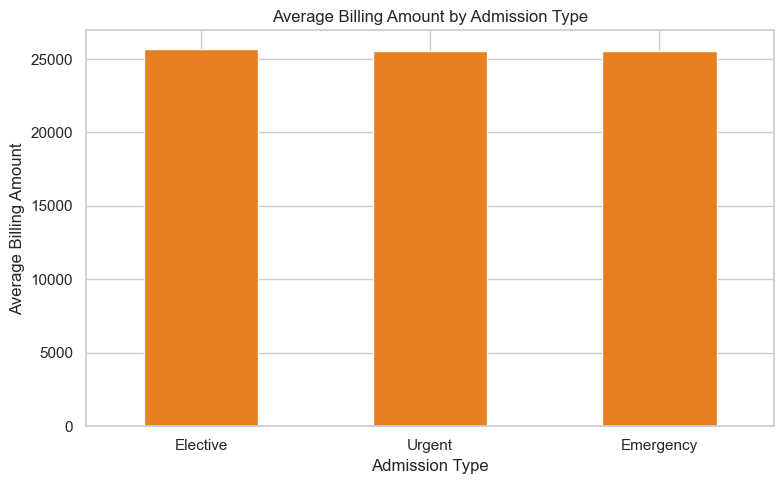

In [32]:
s = df_clean.groupby("Admission Type")["Billing Amount"].mean().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
s.plot(kind="bar", color="#E67E22")
plt.title("Average Billing Amount by Admission Type")
plt.xlabel("Admission Type")
plt.ylabel("Average Billing Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(charts / "admission_type_cost.png", dpi=150, bbox_inches="tight")
plt.show()


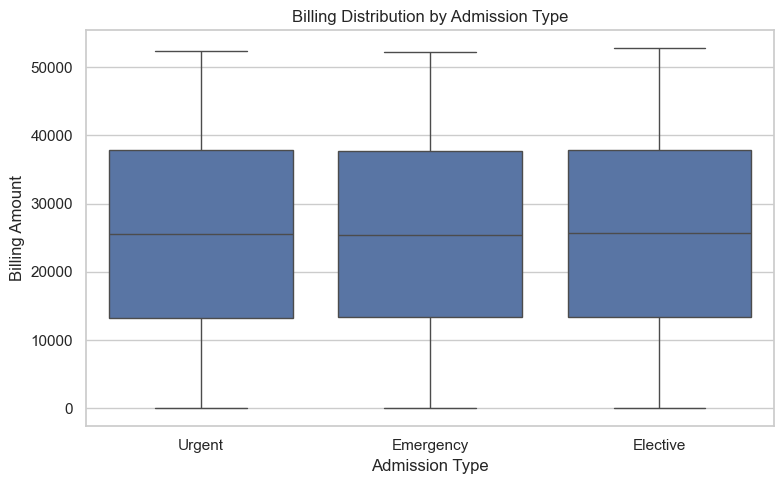

In [33]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="Admission Type", y="Billing Amount")
plt.title("Billing Distribution by Admission Type")
plt.tight_layout()
plt.show()


Elective is slightly highest on average, but the gap is tiny. Box plots look alike. Do not treat emergency as automatically more expensive in this file.


# 23. Chart 4 — Length of Stay Distribution

Histogram: one numeric variable.


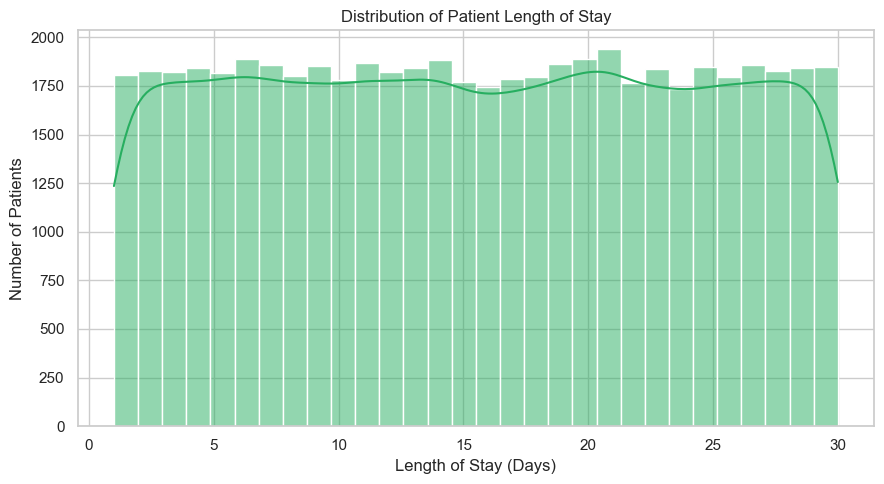

In [34]:
plt.figure(figsize=(9, 5))
sns.histplot(df_clean["Length_of_Stay"], bins=30, kde=True, color="#27AE60")
plt.title("Distribution of Patient Length of Stay")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.savefig(charts / "length_of_stay_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


Stays run 1–30 days. Median is 15. Average is about 15.5. Review patients around day 15 to free beds.


# 24. Chart 5 — Monthly Admission Trend

Line chart: time order.


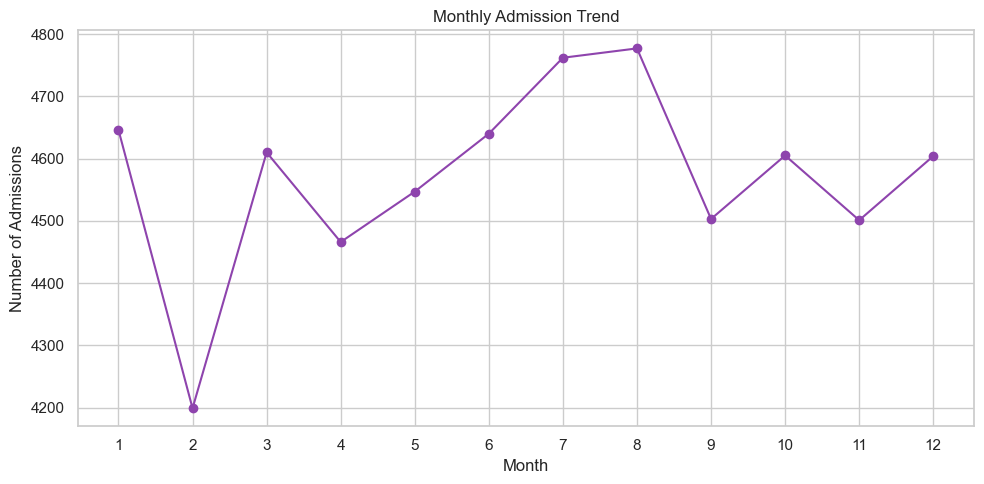

In [35]:
monthly = (df_clean.groupby("Admission_Month").size()
           .reset_index(name="Admission_Count").sort_values("Admission_Month"))
plt.figure(figsize=(10, 5))
plt.plot(monthly["Admission_Month"], monthly["Admission_Count"], marker="o", color="#8E44AD")
plt.title("Monthly Admission Trend")
plt.xlabel("Month")
plt.ylabel("Number of Admissions")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.savefig(charts / "monthly_admission_trend.png", dpi=150, bbox_inches="tight")
plt.show()


July and August are busiest. February is lowest (also a shorter month). Demand is fairly stable, with a small mid-year lift.


# 25. Chart 6 — Test Results by Medical Condition

Heatmap: two categories.


In [36]:
test_condition_table = pd.crosstab(df_clean["Medical Condition"], df_clean["Test Results"])
display(test_condition_table)


Test Results,Abnormal,Inconclusive,Normal
Medical Condition,,,
Arthritis,3153,3061,2993
Asthma,2972,2992,3113
Cancer,3081,3029,3011
Diabetes,3124,3014,3059
Hypertension,2970,3060,3101
Obesity,3099,3003,3025


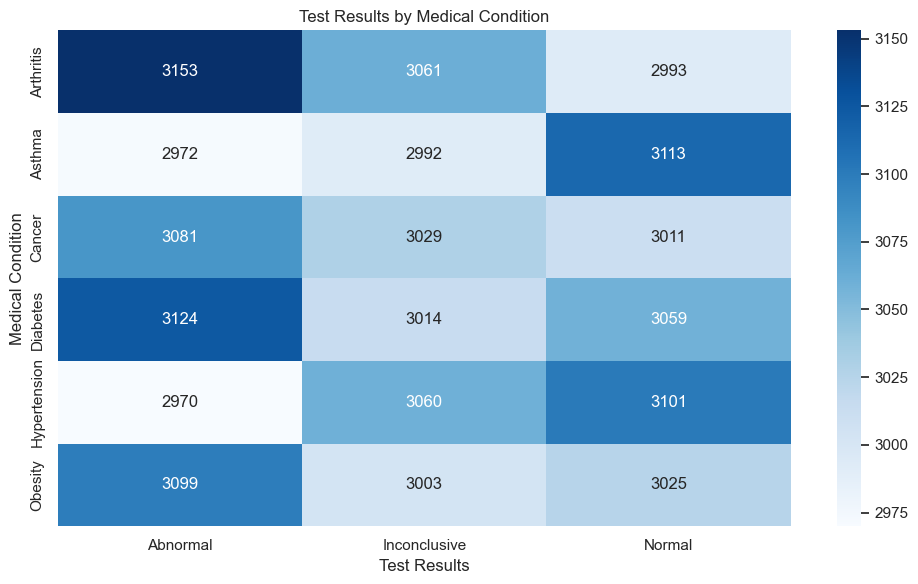

In [37]:
plt.figure(figsize=(10, 6))
sns.heatmap(test_condition_table, annot=True, fmt="d", cmap="Blues")
plt.title("Test Results by Medical Condition")
plt.xlabel("Test Results")
plt.ylabel("Medical Condition")
plt.tight_layout()
plt.savefig(charts / "test_results_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


Abnormal counts are slightly highest for Arthritis and Diabetes. Inconclusive results are common in every condition. Treat inconclusive rate as a hospital-wide quality metric.


# 26. Optional: Billing by Age Group (box plot)


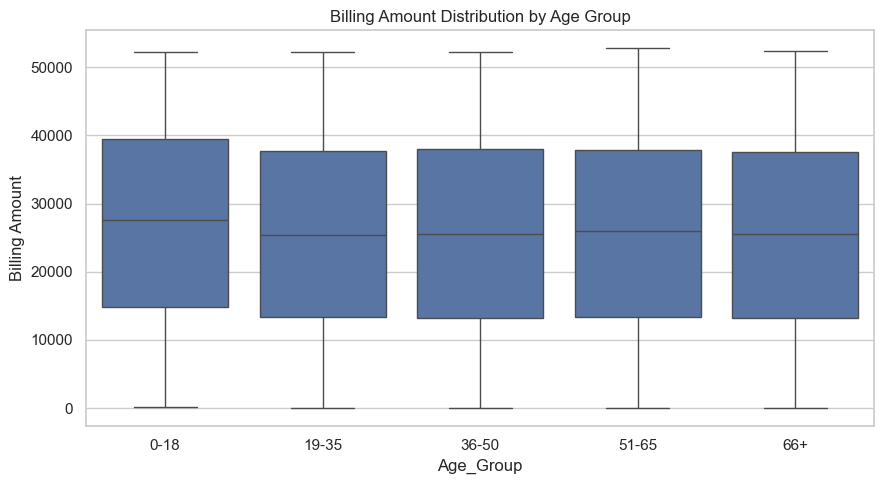

In [38]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x="Age_Group", y="Billing Amount")
plt.title("Billing Amount Distribution by Age Group")
plt.tight_layout()
plt.show()


Medians look similar by age. The bigger age story is volume: 66+ is the largest group.


# 27. Optional: Billing vs Length of Stay (scatter)


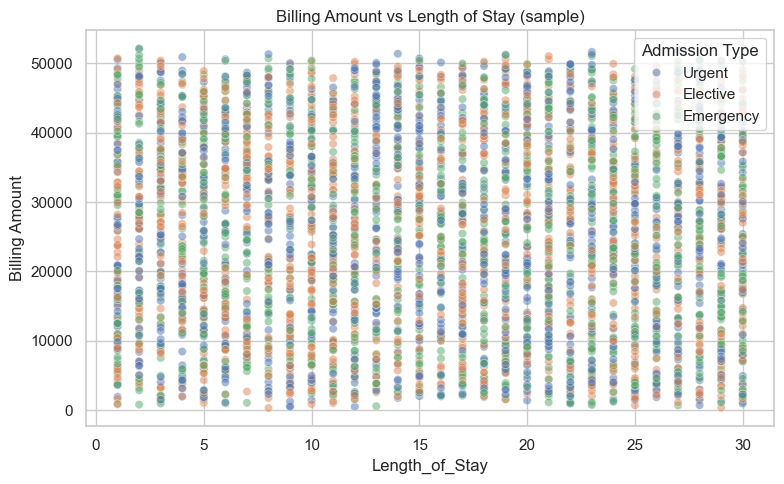

Correlation: -0.0048


In [39]:
sample = df_clean.sample(n=min(4000, len(df_clean)), random_state=42)
plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x="Length_of_Stay", y="Billing Amount", hue="Admission Type", alpha=0.5)
plt.title("Billing Amount vs Length of Stay (sample)")
plt.tight_layout()
plt.show()
print("Correlation:", round(df_clean["Length_of_Stay"].corr(df_clean["Billing Amount"]), 4))


Correlation is about zero in this synthetic file. That is a data limit. In real hospitals extra days usually cost more, so I would not tell finance that stay is unrelated to cost without a richer cost file.


# 28. Executive Summary

This project analysed about 55,500 synthetic hospital records (54,860 after removing duplicate visits and invalid negative bills). The aim was to find demand, billing drivers, stay length, insurer mix, and test-result pressure.

Three key findings: admissions and revenue are spread across six conditions; elective, urgent, and emergency average bills are almost the same; typical stay is about 15 days and inconclusive tests are common everywhere.

Next steps: plan capacity for several chronic conditions together, review patients around day 15, and track inconclusive tests as an operations KPI.


# 29. Recommendations

1. Because the six conditions have similar volume, plan shared pathways for diabetes, arthritis, hypertension, obesity, asthma, and cancer support.
2. Because average bills are similar by admission type, add condition, age group, and length of stay to the finance dashboard.
3. Because typical stay is 15 days, run a weekly long-stay huddle for patients at or beyond that point.
4. Because inconclusive tests appear in every condition, track inconclusive rate as a quality metric.
5. Because five insurers share the work, contract and denial follow-up should cover all five payers.
6. Because hospital names are too fragmented to rank sites, standardise hospital names at data entry.


# 30. Conclusion

This project used Python and Pandas to load, inspect, clean, engineer features, group, filter, chart, and interpret healthcare operations data. It shows both technical steps and business thinking expected of a junior Data Analyst / Business Intelligence Analyst.
